Best fit parameters: b=0.0365, loc=0.0017, scale=0.0083
Best fit parameters: b=0.0000, loc=0.0000, scale=0.0167
Best fit parameters: b=0.0161, loc=0.0000, scale=0.0278
Best fit parameters: b=0.0380, loc=0.0000, scale=0.0464
Best fit parameters: b=0.0640, loc=0.0000, scale=0.0774
Fitting failed for init values b=1.0, loc=0.00012915496650148838: Optimization error: MLE optimization failed:
Status: 4
Message: Inequality constraints incompatible
Try different initial values or bounds.
Best fit parameters: b=0.0953, loc=0.0000, scale=0.1292
Best fit parameters: b=0.1336, loc=0.0000, scale=0.2154
Best fit parameters: b=0.1814, loc=0.0000, scale=0.3594
Best fit parameters: b=0.1385, loc=0.0000, scale=0.5995
Best fit parameters: b=0.1960, loc=0.0000, scale=1.0000


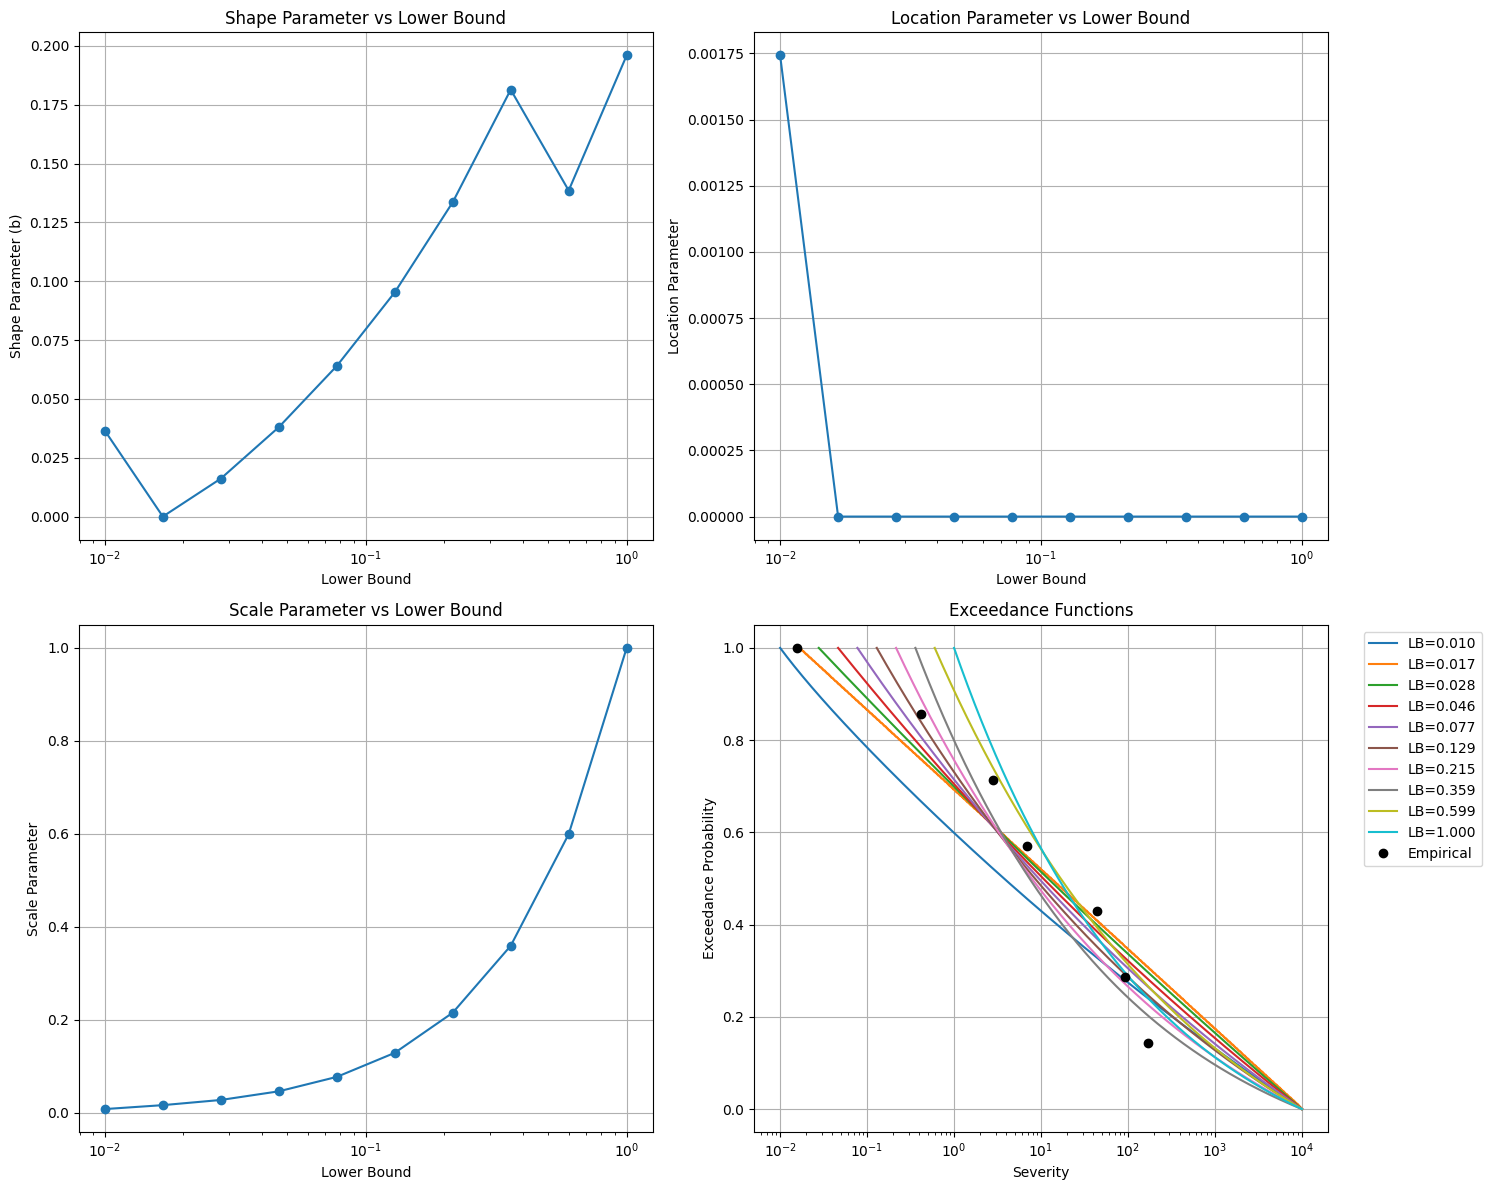

In [15]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from scipy.stats import truncpareto

# Add parent directory to path to import custom modules
sys.path.append(str(Path.cwd().parent))
from scripts.fit_distributions import fit_truncated_pareto

# Load and prep data as in fit_distributions.py
YRMIN = 1900
SMU_THRESH = 0.01

# Read epidemic data
df = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

# Subset data
df = df[(df["year_start"] >= YRMIN)].reset_index(drop=True)
df = df[(df["severity_smu"] >= SMU_THRESH)]

# Replace COVID severity with ex ante estimate
with open("../../data/clean/inverted_covid_severity.yaml") as f:
    estimated_covid_severity = yaml.safe_load(f)
ex_ante_covid_severity = estimated_covid_severity['ex_ante_severity']
df.loc[df['disease'] == 'covid-19', 'severity_smu'] = ex_ante_covid_severity

# Get all viral pandemics
df_all = df[df['disease'].isin(['influenza', 'covid-19', 'ebola', 'hiv/aids'])].reset_index(drop=True)

# Try different lower bounds with expanded init values
lower_bounds = np.logspace(-2, 0, 10)  # 10 points between 0.01 and 0.1
params = []

# Test different initialization values across wider range of shape parameters
def get_init_values(lower_bound):
    """Generate a list of initial values for fitting truncated Pareto distribution.
    
    Args:
        lower_bound: The lower bound of the distribution
        
    Returns:
        List of tuples containing (shape parameter b, location parameter loc) pairs
    """
    return [
        (0.01, lower_bound * 0.1),   # Very small shape parameter
        (0.1, lower_bound * 0.01),   # Small shape parameter
        (1.0, lower_bound * 0.001),  # Shape parameter of 1
        (10.0, lower_bound * 0.2),   # Large shape parameter
        (100.0, lower_bound * 0.05), # Very large shape parameter
        (0.05, lower_bound * 0.005), # Another small shape parameter
        (0.5, lower_bound * 0.15),   # Medium-small shape parameter
        (5.0, lower_bound * 0.02),   # Medium-large shape parameter
        (50.0, lower_bound * 0.002)  # Another large shape parameter
    ]
for lower_bound in lower_bounds:
    init_values = get_init_values(lower_bound)
    # Filter data above lower bound
    severity_values = df_all['severity_smu'].values
    severity_values = severity_values[severity_values >= lower_bound]
    
    # Skip if no values above lower bound
    if len(severity_values) == 0:
        print(f"No values above lower bound {lower_bound}")
        continue
        
    try:
        fit, dist_params = fit_truncated_pareto(
            severity_values,
            lower_bound, 
            init_values=init_values,
            verbose=False
        )
        params.append({
            'lower_bound': lower_bound,
            'b': fit[0],
            'loc': fit[1], 
            'scale': fit[2],
            'dist_params': dist_params
        })
    except RuntimeError:
        print(f"Failed to fit for lower bound {lower_bound}")
        continue

# Convert to DataFrame for plotting
params_df = pd.DataFrame(params)

# Create figure with 4 subplots (3 for parameters, 1 for exceedance functions)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot parameter values vs lower bound
ax1.semilogx(params_df['lower_bound'], params_df['b'], 'o-')
ax1.set_xlabel('Lower Bound')
ax1.set_ylabel('Shape Parameter (b)')
ax1.set_title('Shape Parameter vs Lower Bound')
ax1.grid(True)

ax2.semilogx(params_df['lower_bound'], params_df['loc'], 'o-')
ax2.set_xlabel('Lower Bound')
ax2.set_ylabel('Location Parameter')
ax2.set_title('Location Parameter vs Lower Bound')
ax2.grid(True)

ax3.semilogx(params_df['lower_bound'], params_df['scale'], 'o-')
ax3.set_xlabel('Lower Bound')
ax3.set_ylabel('Scale Parameter')
ax3.set_title('Scale Parameter vs Lower Bound')
ax3.grid(True)

# Plot exceedance functions
for _, row in params_df.iterrows():
    dist_params = row['dist_params']['params']
    b, c, loc, scale = dist_params['b'], dist_params['c'], dist_params['loc'], dist_params['scale']
    lower = scale + loc
    upper = c * scale + loc
    
    # Generate points for exceedance function
    x = np.logspace(np.log10(lower), np.log10(upper), 1000)
    pd = truncpareto(b=b, c=c, loc=loc, scale=scale)
    exceedance = 1 - pd.cdf(x)
    
    ax4.semilogx(x, exceedance, '-', label=f'LB={row["lower_bound"]:.3f}')

# Plot empirical exceedance
df_sorted = df_all.sort_values('severity_smu', ascending=False)
empirical_exceed = np.arange(1, len(df_sorted) + 1) / len(df_sorted)
ax4.semilogx(df_sorted['severity_smu'], empirical_exceed, 'ko', label='Empirical')

ax4.set_xlabel('Severity')
ax4.set_ylabel('Exceedance Probability')
ax4.set_title('Exceedance Functions')
ax4.grid(True)
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [9]:
params_df

,lower_bound,b,loc,scale,dist_params
0,0.010000,4.163336e-17,0.000374,0.009626,"{'dist_family': 'TruncatedPareto', 'params': {..."
1,0.016681,1.635378e-09,0.015703,0.000978,"{'dist_family': 'TruncatedPareto', 'params': {..."
2,0.027826,1.617185e-06,0.015706,0.012120,"{'dist_family': 'TruncatedPareto', 'params': {..."
3,0.077426,1.151959e-01,0.015705,0.061721,"{'dist_family': 'TruncatedPareto', 'params': {..."
4,0.129155,1.147021e+00,0.015704,0.113451,"{'dist_family': 'TruncatedPareto', 'params': {..."
5,0.215443,3.885194e-01,0.015635,0.199808,"{'dist_family': 'TruncatedPareto', 'params': {..."
6,0.599484,5.679693e-01,0.015705,0.583779,"{'dist_family': 'TruncatedPareto', 'params': {..."


In [10]:
lower_bounds

array([0.01      , 0.01668101, 0.02782559, 0.04641589, 0.07742637,
       0.12915497, 0.21544347, 0.35938137, 0.59948425, 1.        ])